# Classifier error-mode predictions

Load every v27 final classifier checkpoint and collect predictions on the clean test split. The final combined artifact is `outputs/classifier_error_modes/solubility/v27/classifier_predictions.csv`.

The inference cell is restart-safe:

- If the combined output already exists, it is loaded immediately and no checkpoint forward pass runs.
- Otherwise, each missing per-run output is generated from `best_model.pt`; completed per-run outputs are reused after an interrupted run.
- The per-run outputs are concatenated and atomically saved as the combined CSV.

Delete the combined CSV and the relevant per-run CSVs under the same output directory when a deliberate re-run is needed.

In [1]:
from dataclasses import fields
from pathlib import Path
import gc
import json
import sys

import numpy as np
import pandas as pd
import torch

# Resolve the repository root whether Jupyter starts in the repo or Code/notebooks.
PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'Code' / 'src' / 'training' / 'train_classifier.py').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Code.src.training.train_classifier import (
    ClassifierRunConfig,
    _create_sequence_dataloader,
    _ensure_embedding_caches,
    create_model,
)
from Code.src.utils.classifier_data import configure_reproducibility
from Code.src.utils.embedding_cache import cached_embedding_dataloader

DATASET = 'solubility'
VERSION = 'v27'
BATCH_SIZE = 16
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
CLASSIFIER_CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'classifier'
CLASSIFIER_RESULTS_ROOT = PROJECT_ROOT / 'Code' / 'results' / 'classifier'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'classifier_error_modes' / DATASET / VERSION
COMBINED_OUTPUT_PATH = OUTPUT_ROOT / 'classifier_predictions.csv'
RUN_OUTPUT_ROOT = OUTPUT_ROOT / 'runs'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')
print(f'Combined prediction cache: {COMBINED_OUTPUT_PATH}')

Project root: /Users/josh/GWU/protein-sequence-augmentation
Device: mps
Combined prediction cache: /Users/josh/GWU/protein-sequence-augmentation/outputs/classifier_error_modes/solubility/v27/classifier_predictions.csv


## Inference helpers

Frozen runs contain a trained classifier head over cached embeddings, so their test embeddings are built or loaded through the project cache before applying the head. Unfrozen checkpoints contain the full fine-tuned encoder and head and therefore run directly on sequence batches.

In [2]:
REQUIRED_PREDICTION_COLUMNS = {
    'checkpoint', 'encoder_mode', 'head_type', 'representation', 'seed',
    'sample_index', 'sample_id', 'sequence', 'sequence_length',
    'true_label', 'predicted_label', 'confidence', 'correct',
    'probability_class_0', 'probability_class_1',
}


def local_project_path(value):
    """Map a saved relative or remote project path onto this checkout."""
    if value is None:
        return None
    path = Path(value)
    if not path.is_absolute():
        return PROJECT_ROOT / path
    if path.exists():
        return path
    for anchor in ('checkpoints', 'data', 'Code'):
        if anchor in path.parts:
            return PROJECT_ROOT / Path(*path.parts[path.parts.index(anchor):])
    return path


def discover_final_checkpoints():
    version_root = CLASSIFIER_CHECKPOINT_ROOT / DATASET / VERSION
    paths = sorted(version_root.glob('*/final/*/*/seed_*/best_model.pt'))
    if not paths:
        raise FileNotFoundError(f'No final best_model.pt checkpoints found under {version_root}')
    return paths


def config_for_checkpoint(checkpoint_path):
    relative_run = checkpoint_path.parent.relative_to(CLASSIFIER_CHECKPOINT_ROOT)
    config_path = CLASSIFIER_RESULTS_ROOT / relative_run / 'config.json'
    if not config_path.is_file():
        raise FileNotFoundError(f'Missing run config for {checkpoint_path}: {config_path}')

    with config_path.open(encoding='utf-8') as handle:
        saved = json.load(handle)
    field_names = {field.name for field in fields(ClassifierRunConfig)}
    values = {name: saved[name] for name in field_names if name in saved}
    values.update(
        data_dir=str(PROJECT_ROOT / 'data' / 'processed' / 'peer'),
        results_dir=str(CLASSIFIER_RESULTS_ROOT),
        checkpoint_root=str(CLASSIFIER_CHECKPOINT_ROOT),
        embedding_cache_root=str(PROJECT_ROOT / 'data' / 'processed' / 'embeddings'),
        autoencoder_checkpoint=(
            str(local_project_path(saved.get('autoencoder_checkpoint')))
            if saved.get('autoencoder_checkpoint') is not None
            else None
        ),
        batch_size=BATCH_SIZE,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        evaluate_test=True,
        device=str(DEVICE),
    )
    return ClassifierRunConfig(**values)


def output_path_for_checkpoint(checkpoint_path):
    version_root = CLASSIFIER_CHECKPOINT_ROOT / DATASET / VERSION
    relative_run = checkpoint_path.parent.relative_to(version_root)
    return RUN_OUTPUT_ROOT / relative_run / 'predictions.csv'


def atomic_csv_save(frame, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + '.tmp')
    try:
        frame.to_csv(temporary_path, index=False)
        temporary_path.replace(path)
    finally:
        temporary_path.unlink(missing_ok=True)


def load_prediction_csv(path):
    frame = pd.read_csv(path)
    missing = REQUIRED_PREDICTION_COLUMNS.difference(frame.columns)
    if missing:
        raise ValueError(f'Prediction cache {path} is missing columns: {sorted(missing)}')
    if frame.empty:
        raise ValueError(f'Prediction cache is empty: {path}')
    return frame


def load_classifier_state(checkpoint_path):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    if not isinstance(checkpoint, dict) or 'model_state_dict' not in checkpoint:
        raise ValueError(f'Invalid classifier checkpoint: {checkpoint_path}')
    return checkpoint['model_state_dict']


def as_list(value):
    if torch.is_tensor(value):
        return value.detach().cpu().reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (str, bytes)):
        return [value]
    return list(value)

In [3]:
def run_checkpoint_forward_pass(checkpoint_path):
    config = config_for_checkpoint(checkpoint_path)
    configure_reproducibility(config.seed, config.deterministic)

    if config.cache_embeddings:
        # This mirrors frozen training: recreate/load the representation cache,
        # then load the head-only checkpoint into a cached-embedding classifier.
        payload = _ensure_embedding_caches(config, ['test'])['test']
        test_loader = cached_embedding_dataloader(
            config, payload, shuffle=False, offset=2
        )
        model = create_model(config, use_cached_embeddings=True)
    else:
        test_loader = _create_sequence_dataloader(
            config, 'test', shuffle=False, offset=2
        )
        model = create_model(config, use_cached_embeddings=False)

    model.load_state_dict(load_classifier_state(checkpoint_path), strict=True)
    model.eval()
    checkpoint_label = str(checkpoint_path.relative_to(PROJECT_ROOT))
    batch_frames = []
    sample_offset = 0

    with torch.inference_mode():
        for batch in test_loader:
            logits = model(batch)
            if logits.ndim != 2 or logits.shape[1] != config.num_classes:
                raise ValueError(
                    f'Expected [batch, {config.num_classes}] logits from {checkpoint_path}, '
                    f'got {tuple(logits.shape)}'
                )
            if not torch.isfinite(logits).all().item():
                raise ValueError(f'Non-finite logits produced by {checkpoint_path}')

            probabilities = torch.softmax(logits, dim=1).detach().cpu().numpy()
            predicted = probabilities.argmax(axis=1)
            labels = batch['label'].detach().cpu().long().reshape(-1).numpy()
            sequences = [str(sequence) for sequence in as_list(batch['sequence'])]
            lengths = [int(length) for length in as_list(batch['length'])]
            sample_ids = as_list(batch['sample_id'])
            batch_size = len(labels)

            part = pd.DataFrame({
                'checkpoint': checkpoint_label,
                'encoder_mode': config.encoder_mode,
                'head_type': config.head_type,
                'representation': config.representation,
                'seed': config.seed,
                'sample_index': np.arange(sample_offset, sample_offset + batch_size),
                'sample_id': sample_ids,
                'sequence': sequences,
                'sequence_length': lengths,
                'true_label': labels,
                'predicted_label': predicted,
                'confidence': probabilities.max(axis=1),
                'correct': labels == predicted,
            })
            for class_index in range(config.num_classes):
                part[f'probability_class_{class_index}'] = probabilities[:, class_index]
            batch_frames.append(part)
            sample_offset += batch_size

    if not batch_frames:
        raise ValueError(f'Test loader produced no samples for {checkpoint_path}')
    predictions = pd.concat(batch_frames, ignore_index=True)

    del model, test_loader
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE.type == 'mps':
        torch.mps.empty_cache()
    return predictions


def get_or_create_run_predictions(checkpoint_path):
    output_path = output_path_for_checkpoint(checkpoint_path)
    if output_path.is_file():
        print(f'Loading cached run: {output_path.relative_to(PROJECT_ROOT)}')
        return load_prediction_csv(output_path)

    print(f'Running forward pass: {checkpoint_path.relative_to(PROJECT_ROOT)}')
    frame = run_checkpoint_forward_pass(checkpoint_path)
    atomic_csv_save(frame, output_path)
    print(f'Saved {len(frame):,} predictions: {output_path.relative_to(PROJECT_ROOT)}')
    return frame

## Load cached predictions or run inference

In [4]:
if COMBINED_OUTPUT_PATH.is_file():
    classifier_predictions = load_prediction_csv(COMBINED_OUTPUT_PATH)
    print(
        f'Loaded {len(classifier_predictions):,} cached predictions from '
        f'{COMBINED_OUTPUT_PATH.relative_to(PROJECT_ROOT)}; no forward passes were run.'
    )
else:
    final_checkpoints = discover_final_checkpoints()
    print(f'Found {len(final_checkpoints)} final checkpoints.')
    run_predictions = [
        get_or_create_run_predictions(checkpoint_path)
        for checkpoint_path in final_checkpoints
    ]
    classifier_predictions = pd.concat(run_predictions, ignore_index=True)
    atomic_csv_save(classifier_predictions, COMBINED_OUTPUT_PATH)
    print(
        f'Saved {len(classifier_predictions):,} combined predictions to '
        f'{COMBINED_OUTPUT_PATH.relative_to(PROJECT_ROOT)}'
    )

Found 16 final checkpoints.
Running forward pass: checkpoints/classifier/solubility/v27/frozen/final/linear/esm2/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl
Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/frozen/final/linear/esm2/seed_42/predictions.csv
Running forward pass: checkpoints/classifier/solubility/v27/frozen/final/linear/random_autoencoder/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:86: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/frozen/final/linear/random_autoencoder/seed_42/predictions.csv
Running forward pass: checkpoints/classifier/solubility/v27/frozen/final/linear/trained_autoencoder/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:86: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/frozen/final/linear/trained_autoencoder/seed_42/predictions.csv
Running forward pass: checkpoints/classifier/solubility/v27/frozen/final/linear/trained_autoencoder+esm2/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl


...

Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/unfrozen/final/mlp/random_autoencoder/seed_42/predictions.csv
Running forward pass: checkpoints/classifier/solubility/v27/unfrozen/final/mlp/trained_autoencoder/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:86: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/unfrozen/final/mlp/trained_autoencoder/seed_42/predictions.csv
Running forward pass: checkpoints/classifier/solubility/v27/unfrozen/final/mlp/trained_autoencoder+esm2/seed_42/best_model.pt
[cache] Loaded 1999 examples from cache: solubility_test_classification_char_sequence_label_False_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_96e3c787cf60.pkl


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:86: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


Saved 1,999 predictions: outputs/classifier_error_modes/solubility/v27/runs/unfrozen/final/mlp/trained_autoencoder+esm2/seed_42/predictions.csv
Saved 31,984 combined predictions to outputs/classifier_error_modes/solubility/v27/classifier_predictions.csv


In [5]:
prediction_summary = (
    classifier_predictions
    .groupby(['encoder_mode', 'head_type', 'representation', 'seed'], observed=True)
    .agg(
        samples=('sample_index', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean'),
    )
    .reset_index()
    .sort_values(['encoder_mode', 'head_type', 'representation', 'seed'])
)
display(prediction_summary)
display(classifier_predictions.head())

,encoder_mode,head_type,representation,seed,samples,accuracy,mean_confidence
0,fine_tuned,linear,esm2,42,1999,0.736368,0.783071
1,fine_tuned,linear,trained_autoencoder,42,1999,0.698849,0.758760
2,fine_tuned,linear,trained_autoencoder+esm2,42,1999,0.728364,0.798452
3,fine_tuned,mlp,esm2,42,1999,0.749375,0.791192
4,fine_tuned,mlp,trained_autoencoder,42,1999,0.705353,0.748880
5,fine_tuned,mlp,trained_autoencoder+esm2,42,1999,0.737869,0.775628
6,from_scratch,linear,random_autoencoder,42,1999,0.699850,0.772153
7,from_scratch,mlp,random_autoencoder,42,1999,0.718359,0.772873
8,frozen,linear,esm2,42,1999,0.603302,0.655400
9,frozen,linear,random_autoencoder,42,1999,0.536768,0.596183


,checkpoint,encoder_mode,head_type,representation,seed,sample_index,sample_id,sequence,sequence_length,true_label,predicted_label,confidence,correct,probability_class_0,probability_class_1
0,checkpoints/classifier/solubility/v27/frozen/f...,frozen,linear,esm2,42,0,0,MLSVRIAAAVARALPRRAGLVSKNALGSSFVGTRNLHASNTRLQKT...,553,1,0,0.733131,False,0.733131,0.266869
1,checkpoints/classifier/solubility/v27/frozen/f...,frozen,linear,esm2,42,1,1,MDHMISENGETSAEGSICGYDSLHQLLSANLKPELYQEVNRLLLGR...,408,1,0,0.665322,False,0.665322,0.334678
2,checkpoints/classifier/solubility/v27/frozen/f...,frozen,linear,esm2,42,2,2,MLSASANMAAALRAAGALLREPLVHGSSRACQPWRCQSGAAVAATT...,420,1,0,0.579470,False,0.579470,0.420530
3,checkpoints/classifier/solubility/v27/frozen/f...,frozen,linear,esm2,42,3,3,MANMLVASSSKTLPTTTTTTITPKPKFPLLKTPLLKLSPPQLPPLK...,222,1,0,0.819558,False,0.819558,0.180442
4,checkpoints/classifier/solubility/v27/frozen/f...,frozen,linear,esm2,42,4,4,MAVVSTSLASQITNPNSAVSTQFSGLRRSFLKLENSVSTQSSFFQN...,322,1,1,0.508256,True,0.491744,0.508256


## Are the failure modes consistent across models?

Accuracy alone cannot show whether the final models learned different signals. This section compares models at the example level using complementary views:

- **Error-set Jaccard similarity:** the fraction of the union of two models' errors that both models share. This focuses on failure overlap without being inflated by easy examples both models classify correctly.
- **Prediction agreement and probability correlation:** whether models make the same decisions and rank examples similarly.
- **Pairwise oracle lift:** the accuracy gain available if a pair is counted correct whenever either model is correct. Positive lift indicates complementary errors.
- **Unanimous versus mixed outcomes:** how many test examples are easy for every model, hard for every model, or separate the models.
- **Length and class error profiles:** whether broad structural failure modes remain consistent even when individual errors differ.

In [6]:
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

comparison = classifier_predictions.copy()
comparison['model_id'] = (
    comparison['encoder_mode'].astype(str) + ' | '
    + comparison['head_type'].astype(str) + ' | '
    + comparison['representation'].astype(str) + ' | seed='
    + comparison['seed'].astype(str)
)
comparison['correct'] = (
    comparison['correct'].astype(str).str.lower().map({'true': True, 'false': False})
)
if comparison['correct'].isna().any():
    raise ValueError("The 'correct' column contains values other than True/False.")

duplicate_rows = comparison.duplicated(['sample_id', 'model_id'])
if duplicate_rows.any():
    raise ValueError('Each model must have exactly one prediction per sample_id.')
if comparison.groupby('sample_id')['true_label'].nunique().max() != 1:
    raise ValueError('True labels are inconsistent across model outputs.')

num_models = comparison['model_id'].nunique()
models_per_sample = comparison.groupby('sample_id')['model_id'].nunique()
if not models_per_sample.eq(num_models).all():
    raise ValueError('Models were not evaluated on identical sample_id sets.')

model_accuracy = comparison.groupby('model_id', observed=True)['correct'].mean().sort_values(ascending=False)
model_order = model_accuracy.index.tolist()
correct_matrix = (
    comparison.pivot(index='sample_id', columns='model_id', values='correct')
    .loc[:, model_order]
    .astype(bool)
)
prediction_matrix = (
    comparison.pivot(index='sample_id', columns='model_id', values='predicted_label')
    .loc[correct_matrix.index, model_order]
    .astype(int)
)
probability_matrix = (
    comparison.pivot(index='sample_id', columns='model_id', values='probability_class_1')
    .loc[correct_matrix.index, model_order]
    .astype(float)
)
sample_metadata = (
    comparison.drop_duplicates('sample_id')
    .set_index('sample_id')[['sequence', 'sequence_length', 'true_label']]
    .loc[correct_matrix.index]
)

correct_count = correct_matrix.sum(axis=1)
model_diversity = pd.DataFrame({
    'accuracy': model_accuracy,
    'errors': (~correct_matrix).sum(axis=0),
    'exclusive_correct': [
        int((correct_matrix[model] & correct_count.eq(1)).sum()) for model in model_order
    ],
    'exclusive_error': [
        int(((~correct_matrix[model]) & correct_count.eq(num_models - 1)).sum())
        for model in model_order
    ],
})
display(model_diversity.style.format({'accuracy': '{:.3f}'}))

,accuracy,errors,exclusive_correct,exclusive_error
model_id,,,,
fine_tuned | mlp | esm2 | seed=42,0.749,501,3,1
fine_tuned | mlp | trained_autoencoder+esm2 | seed=42,0.738,524,1,2
fine_tuned | linear | esm2 | seed=42,0.736,527,2,4
fine_tuned | linear | trained_autoencoder+esm2 | seed=42,0.728,543,0,2
from_scratch | mlp | random_autoencoder | seed=42,0.718,563,4,6
fine_tuned | mlp | trained_autoencoder | seed=42,0.705,589,0,0
frozen | mlp | trained_autoencoder+esm2 | seed=42,0.705,589,6,4
from_scratch | linear | random_autoencoder | seed=42,0.700,600,2,9
fine_tuned | linear | trained_autoencoder | seed=42,0.699,602,1,25


In [7]:
pairwise_rows = []
for model_a, model_b in combinations(model_order, 2):
    correct_a = correct_matrix[model_a]
    correct_b = correct_matrix[model_b]
    error_a = ~correct_a
    error_b = ~correct_b
    shared_errors = int((error_a & error_b).sum())
    error_union = int((error_a | error_b).sum())
    pair_oracle_accuracy = float((correct_a | correct_b).mean())
    pairwise_rows.append({
        'model_a': model_a,
        'model_b': model_b,
        'error_jaccard': shared_errors / error_union if error_union else 1.0,
        'shared_errors': shared_errors,
        'error_union': error_union,
        'correctness_agreement': float(correct_a.eq(correct_b).mean()),
        'prediction_agreement': float(prediction_matrix[model_a].eq(prediction_matrix[model_b]).mean()),
        'probability_correlation': float(probability_matrix[model_a].corr(probability_matrix[model_b])),
        'disagreement_rate': float(prediction_matrix[model_a].ne(prediction_matrix[model_b]).mean()),
        'pair_oracle_accuracy': pair_oracle_accuracy,
        'oracle_lift': pair_oracle_accuracy - max(float(correct_a.mean()), float(correct_b.mean())),
    })

pairwise_comparison = pd.DataFrame(pairwise_rows)
if pairwise_comparison.empty:
    raise ValueError('At least two model outputs are required for comparison.')

labels = sample_metadata['true_label'].astype(int)
soft_ensemble_predictions = probability_matrix.mean(axis=1).ge(0.5).astype(int)
consistency_summary = pd.Series({
    'models': num_models,
    'test_samples': len(correct_matrix),
    'best_single_model_accuracy': float(model_accuracy.max()),
    'soft_ensemble_accuracy': float(soft_ensemble_predictions.eq(labels).mean()),
    'all_model_oracle_accuracy': float(correct_matrix.any(axis=1).mean()),
    'all_models_correct_fraction': float(correct_matrix.all(axis=1).mean()),
    'all_models_wrong_fraction': float((~correct_matrix).all(axis=1).mean()),
    'mixed_outcome_fraction': float((correct_count.gt(0) & correct_count.lt(num_models)).mean()),
    'mean_pairwise_error_jaccard': float(pairwise_comparison['error_jaccard'].mean()),
    'mean_pairwise_prediction_agreement': float(pairwise_comparison['prediction_agreement'].mean()),
    'mean_pairwise_probability_correlation': float(pairwise_comparison['probability_correlation'].mean()),
    'maximum_pairwise_oracle_lift': float(pairwise_comparison['oracle_lift'].max()),
})
display(consistency_summary.to_frame('value').style.format({'value': '{:.4f}'}))
display(
    pairwise_comparison.sort_values(
        ['oracle_lift', 'error_jaccard'], ascending=[False, True]
    ).head(15).style.format({
        'error_jaccard': '{:.3f}',
        'correctness_agreement': '{:.3f}',
        'prediction_agreement': '{:.3f}',
        'probability_correlation': '{:.3f}',
        'disagreement_rate': '{:.3f}',
        'pair_oracle_accuracy': '{:.3f}',
        'oracle_lift': '{:+.3f}',
    })
)

,value
models,16.0000
test_samples,1999.0000
best_single_model_accuracy,0.7494
soft_ensemble_accuracy,0.7304
all_model_oracle_accuracy,0.9515
all_models_correct_fraction,0.2656
all_models_wrong_fraction,0.0485
mixed_outcome_fraction,0.6858
mean_pairwise_error_jaccard,0.4522
mean_pairwise_prediction_agreement,0.7480


,model_a,model_b,error_jaccard,shared_errors,error_union,correctness_agreement,prediction_agreement,probability_correlation,disagreement_rate,pair_oracle_accuracy,oracle_lift
110,frozen | mlp | esm2 | seed=42,frozen | linear | trained_autoencoder | seed=42,0.402,420,1044,0.688,0.688,0.469,0.312,0.790,+0.145
105,frozen | mlp | trained_autoencoder | seed=42,frozen | mlp | esm2 | seed=42,0.400,395,987,0.704,0.704,0.509,0.296,0.802,+0.139
114,frozen | linear | trained_autoencoder | seed=42,frozen | linear | esm2 | seed=42,0.447,478,1070,0.704,0.704,0.466,0.296,0.761,+0.139
107,frozen | mlp | trained_autoencoder | seed=42,frozen | linear | esm2 | seed=42,0.394,414,1052,0.681,0.681,0.433,0.319,0.793,+0.130
94,fine_tuned | linear | trained_autoencoder | seed=42,frozen | mlp | esm2 | seed=42,0.360,347,964,0.691,0.691,0.460,0.309,0.826,+0.128
85,from_scratch | linear | random_autoencoder | seed=42,frozen | linear | trained_autoencoder+esm2 | seed=42,0.388,355,915,0.720,0.720,0.575,0.280,0.822,+0.123
92,fine_tuned | linear | trained_autoencoder | seed=42,frozen | linear | trained_autoencoder+esm2 | seed=42,0.390,357,915,0.721,0.721,0.592,0.279,0.821,+0.123
96,fine_tuned | linear | trained_autoencoder | seed=42,frozen | linear | esm2 | seed=42,0.347,359,1036,0.661,0.661,0.381,0.339,0.820,+0.122
68,fine_tuned | mlp | trained_autoencoder | seed=42,frozen | linear | trained_autoencoder+esm2 | seed=42,0.390,353,906,0.723,0.723,0.596,0.277,0.823,+0.118
99,frozen | linear | trained_autoencoder+esm2 | seed=42,frozen | mlp | trained_autoencoder | seed=42,0.486,439,904,0.767,0.767,0.700,0.233,0.780,+0.116


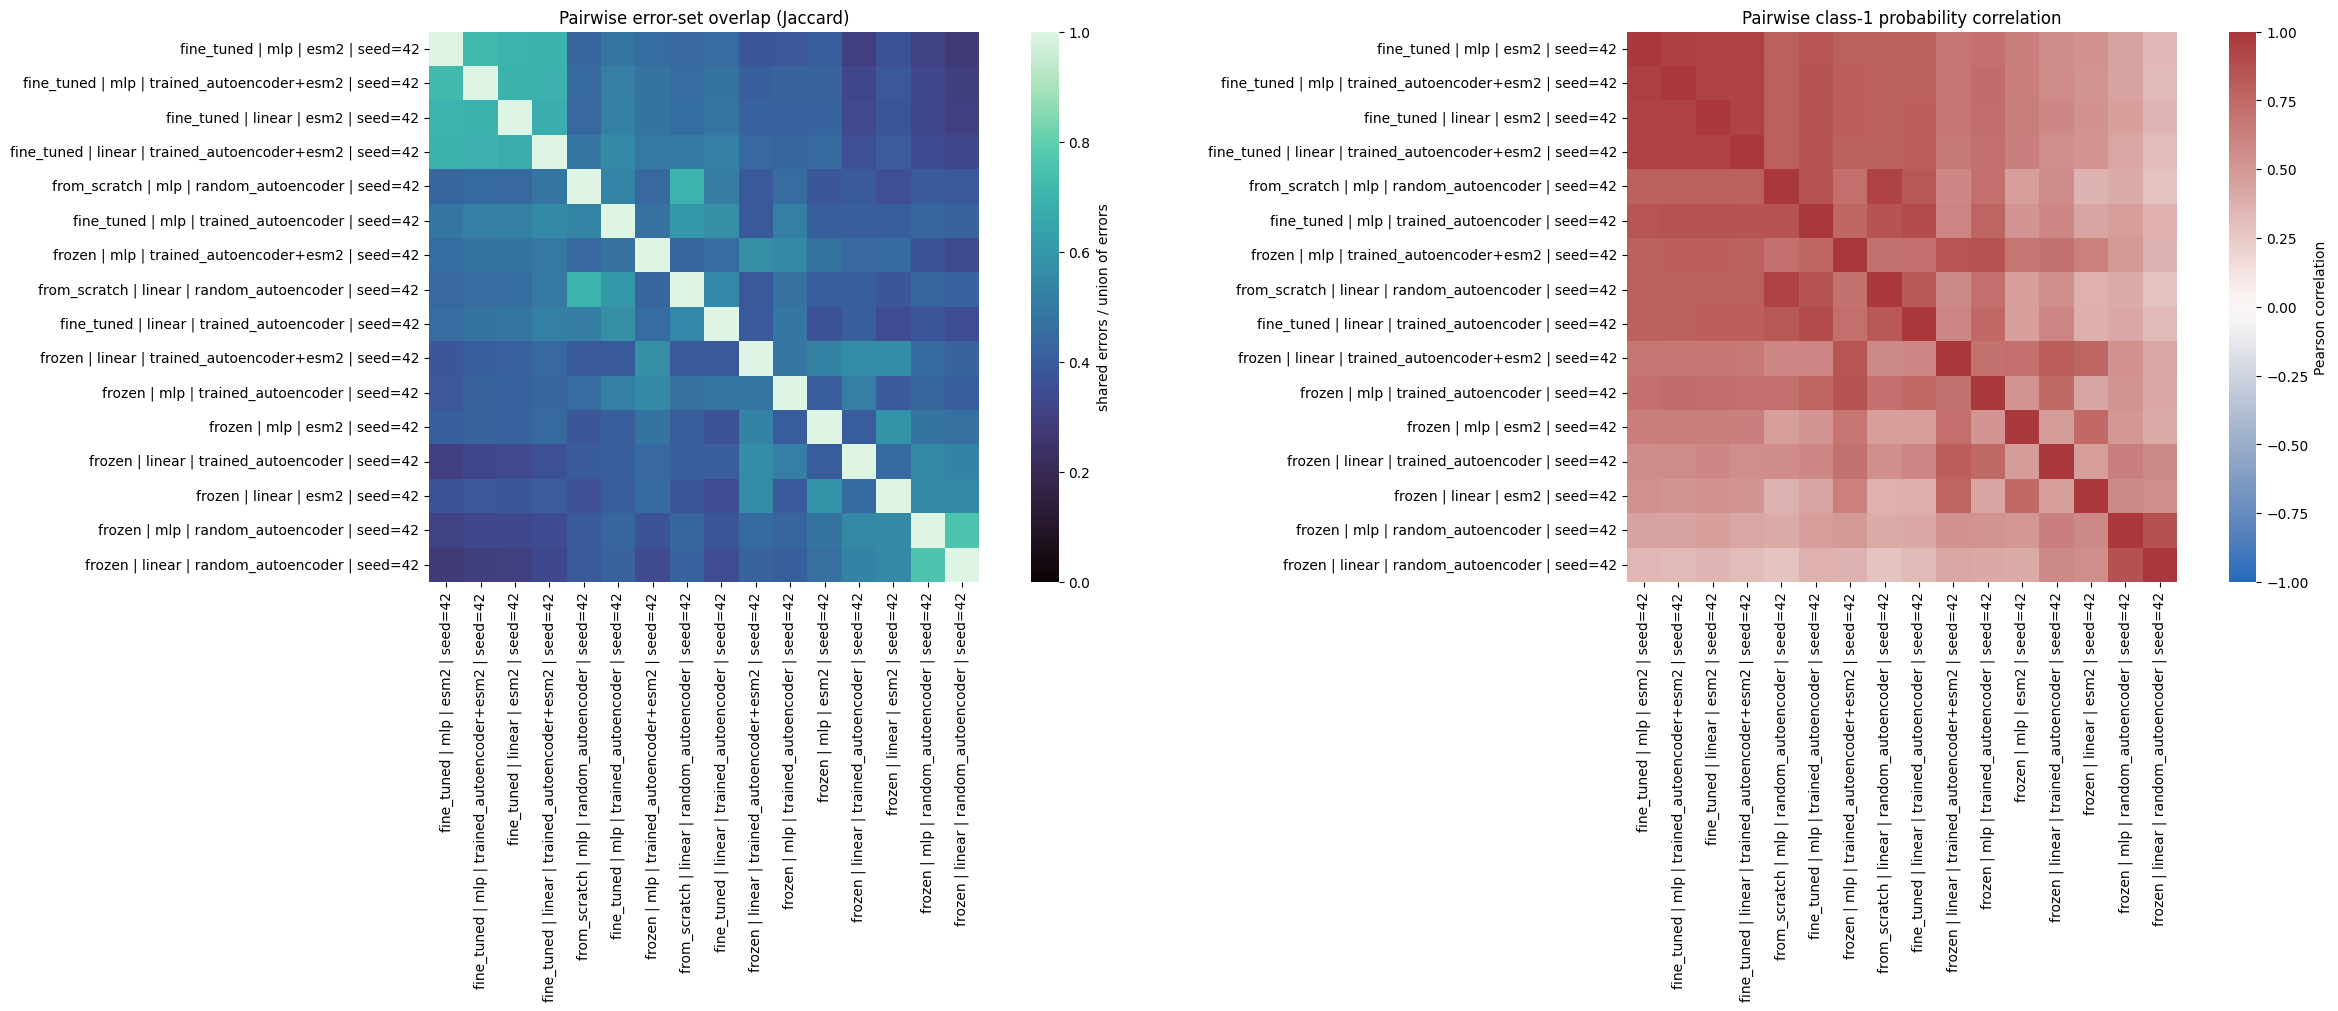

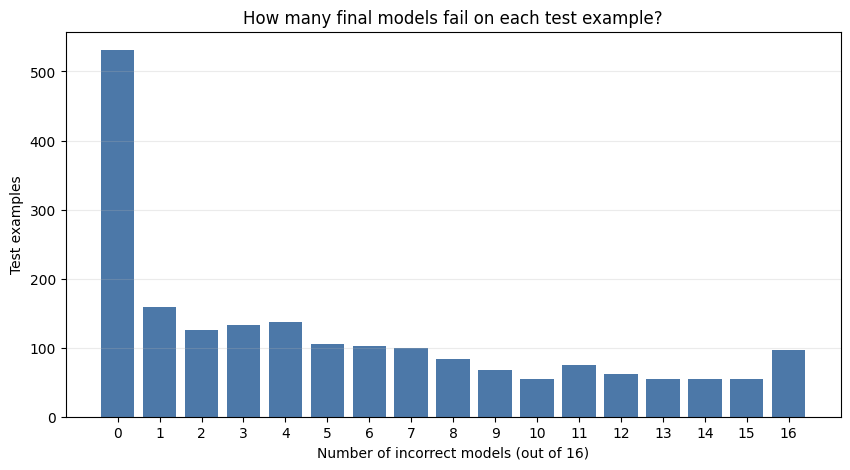

In [8]:
def symmetric_pairwise_matrix(frame, value_column, diagonal_value):
    matrix = pd.DataFrame(diagonal_value, index=model_order, columns=model_order, dtype=float)
    for row in frame.itertuples(index=False):
        value = getattr(row, value_column)
        matrix.loc[row.model_a, row.model_b] = value
        matrix.loc[row.model_b, row.model_a] = value
    return matrix


error_jaccard_matrix = symmetric_pairwise_matrix(pairwise_comparison, 'error_jaccard', 1.0)
probability_correlation_matrix = symmetric_pairwise_matrix(
    pairwise_comparison, 'probability_correlation', 1.0
)

fig, axes = plt.subplots(1, 2, figsize=(24, 10), constrained_layout=True)
sns.heatmap(
    error_jaccard_matrix, vmin=0, vmax=1, cmap='mako', square=True, ax=axes[0],
    cbar_kws={'label': 'shared errors / union of errors'},
)
axes[0].set_title('Pairwise error-set overlap (Jaccard)')
sns.heatmap(
    probability_correlation_matrix, vmin=-1, vmax=1, center=0, cmap='vlag',
    square=True, ax=axes[1], cbar_kws={'label': 'Pearson correlation'},
)
axes[1].set_title('Pairwise class-1 probability correlation')
for axis in axes:
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.tick_params(axis='x', rotation=90)
    axis.tick_params(axis='y', rotation=0)
plt.show()

failure_frequency = (~correct_matrix).sum(axis=1).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(failure_frequency.index, failure_frequency.values, color='#4C78A8')
ax.set(
    title='How many final models fail on each test example?',
    xlabel=f'Number of incorrect models (out of {num_models})',
    ylabel='Test examples',
)
ax.set_xticks(range(num_models + 1))
ax.grid(axis='y', alpha=0.25)
plt.show()

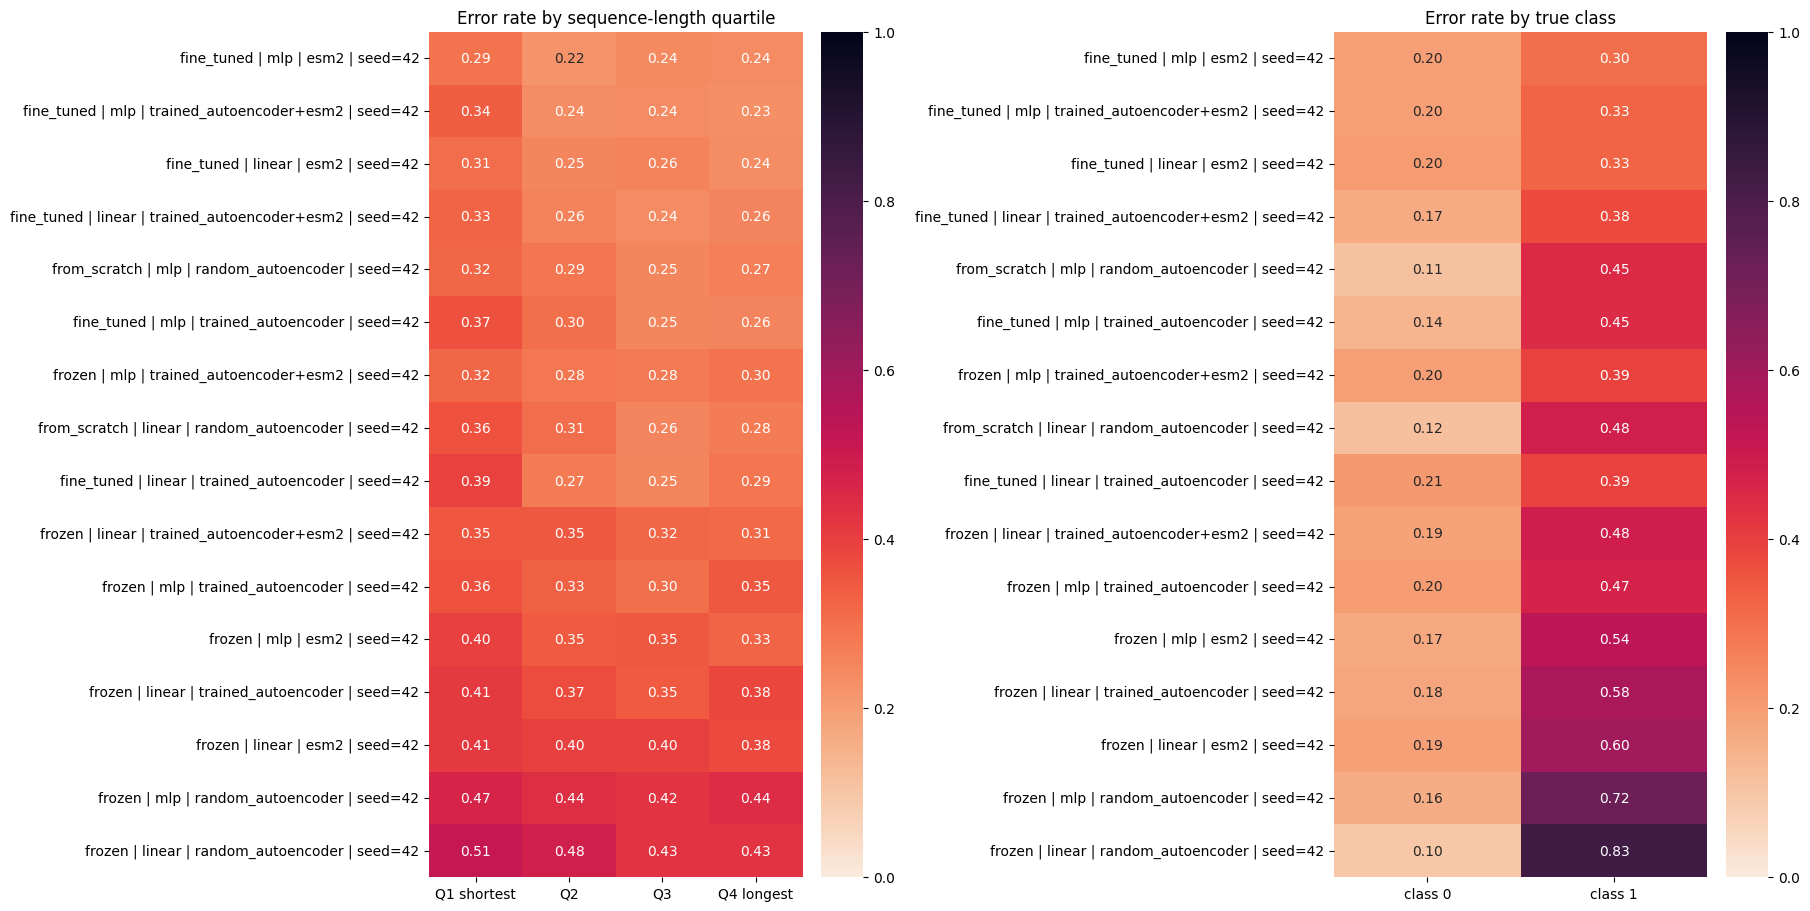

,sequence_length,length_quartile,true_label,models_wrong,model_error_rate,mean_true_class_probability,sequence
sample_id,,,,,,,
374,159,Q1 shortest,1,16,1.000,0.081,MGSDKIHHHHHHMRTLNKDEHNYIKQIANIHETLLSQVESNYKCTKLSIALRYEMICSRLEHTNDKIYIYENEGQLIAFIWGHFSNEKSMVNIELLYVEPQFRKLGIATQLKIALEKWAKTMNAKRISNTIHKNNLPMISLNKDLGYQVSHVKMYKDID
71,258,Q2,1,16,1.000,0.097,MGSDKIHHHHHHMNDFKNQWLRKRTFAIPASRLTGRLTTLKSDVPAADSLFWKLWNGSLDTAVQVLQTDYFKGIAAGTLDPNAYGSLMVQDGYYCFRGRDDYATAATCAQDETLREFFKAKAKSYDEYNETYHQTWHLREASGLIPGTDIKDYADYEAYVAGSLASPYMCVVMLPCEYLWPWIANFLDGYTPTNSLYRFWIEWNGGTPNGAYQMGNMLEQYRDKIDEDKAVEIFNTAMNYELKVFTSSTILTTIENGK
549,248,Q2,1,16,1.000,0.129,HRYIPTLFFHGWGSSYHAETHMADAIVKAGKTQTIVRAMVAKNGTVTLKGHFRSGDYRPIVEVNFANNRSSDYPTVGRWAKNVVVALQRTYGITSFNMVGHSMGNMAITYYLLANAQNKRLPQLRQQVAIAGHFNGILGMDDSPNQMTLNAAGRPNKLRPAYRQLLGLRRVYPRQQVRVLNIYGDKGDGTHSDGSVSNASSRSLRYLVAARARSYREVKLTGKHAQHSQLHENAQVDRLLIDFLWPTH
562,296,Q3,1,16,1.000,0.133,MVKSRIFDNRQLLKEHPEIPHYKEEVVCFMSEYKDRSYPENERYFNRELYMILVLEGRSEILLNGEFIVIEPDMLLVHGANYLTDHLYSSPDIKFITLSISESMRTDDSYLTQITAILLATMRQNKQYTIQLTAYESQIIRNELEVLMRLLNIKHQFLFRRIQAACNALFLDIADFLSRKTIIKKEVSRKDHVLQEFHALVTRNFREEHFVSFYADKLAISEQYLARIVRAGTGKSVNTIINELLIMEARTLLSSTKSTVGDIASRLGFSDAAGFCKFFKRNMGQTPLNYRKGLWI
744,652,Q4 longest,1,16,1.000,0.154,MAHHHHHHMMRHFRISSATQPQCAARTKMTGFNLFTQDMQQERRVLKTKSFKGGRENMRIMAKLWGELPLGQRAMYNTRALQRAALVTRDPEKKNNTFNLLMKLFGRDKVLLKAGNEAFTALMAKSTMHAMSHRDNSRLREKLNVKAFCTSKERSNQSVTSAFKRFISPSMLLFDSFTEMQRSVAPTRKSAFTAITKVLSVSNVTVSGEEYVMKRYSYLSPELQNLFAPISDVEAPFFEMFCADRCASFDWKCFEIIRLFASFRGIEVDLGNNAVQDELFRSLISTDRSRDGIYFRARRSLERLEKLRSSDFGLFITKRLPPSVNVPPAAYGIDSNLDDVSVATLLAETRCGHSVYDDVLTRAAMLRTKEKNKQLAVYNVTRMITTETLSNRQVRVERLKDKVHPQLSAAKPVLKLNAAPAPLCKKNPLSAPVPLKKVPAMVKPQRKRTLPIVTKTTARKAAPVASPDRNAPPAVTLQLVTKRAAGVSRTETKGVPASCRARVKVSAAQKVAAAATKKALKKGTSTSQATTATDEGGDFFAEDFMAEGEGDDVGLEVADKSAGDTNAQVAAPTAPVKQKRKSAGRRAARSHLLAPESMLPATARSQKVIVAHTPTCRKAPRPVCTSPSSPFTPARRKVSLADNIRAQLASFL
708,389,Q4 longest,1,16,1.000,0.160,MLELLFLLLPVAAAYGWYMGRRSAQQNKQDEANRLSRDYVAGVNFLLSNQQDKAVDLFLDMLKEDTGTVEAHLTLGNLFRSRGEVDRAIRIHQTLMESASLTYEQRLLAIQQLGRDYMAAGLYDRAEDMFNQLTDETDFRIGALQQLLQIYQATSEWQKAIDVAERLVKLGKDKQRVEIAHFYCELALQHMASDDLDRAMTLLKKGAAADKNSARVSIMMGRVFMAKGEYAKAVESLQRVISQDRELVSETLEMLQTCYQQLGKTAEWAEFLQRAVEENTGADAELMLADIIEARDGSEAAQVYITRQLQRHPTMRVFHKLMDYHLNEAEEGRAKESLMVLRDMVGEKVRSKPRYRCQKCGFTAYTLYWHCPSCRAWSTIKPIRGLDGL
11,387,Q4 longest,1,16,1.000,0.163,MRRLPPIFALLAMSLMAHVTMSGGRVSASLFALQHNDSNFMAGLAYGMYSLLPALASIHIGRWVDRAGPRRVMNTSLVVMMCGLALPAMWPNLPTVLISAMFGGFGFSSYLLAANVAVSFMPVQHSSERVGMLAWLQIGTSISAVFGPSIAGALIDHAGYRAVFAFMAVTVGIGFVLSRRIELYEGGERAKKHASVAAVLGEVASTPALLRIYLIALALSLAWDGFSFMAPVLGHERGYTASQVGIVLSTFACGTLVTRAALPWLSRRLPEWRMLSVACAVTATVFLVLPIAQSVFLHAALGFVYGLSAGVGQPNILNLIYHSMPPEKAGQGVGLRSMIGGISGLGGPWLFGIIASMLSAAPVFLLIGCVMGSASWQAHRAASATKD
492,374,Q3,1,16,1.000,0.166,MAHHHHHHMKTHISCSYSFIYIHNIVTWINKMVYVNKNEKVKYVFHQVYTLLILKPIPGLKNGLLKYSNKWKDIGKGNYGNTILVRDRKNDHYVMKIINISQMSQKEKRQCLKEVELLSKLNHPFIVKYIESYIEGDTLRIVMKHCKGGDLYHYIQNKKKQNTPIKEKRILIWLTQILTALKFLHSNHILHRDMKSLNILIDSDKRVRLCDFGISKVLENTLDYANTLIGTPYYLSPELCKDKKYSWPSDVWATGCLIYELATFRTPFHSTKGIQQLCYNIRYAPIPDLPNIYSKELNNIYKSMLIREPSYRATVQQLLVSDIVQRQLKLLIEEKIREKQSMKKPLKEKPAIENENSGANEQEVKTLLLDVVDT
298,92,Q1 shortest,1,16,1.000,0.176,MGHHHHHHSHRTRGRPTRPGLKMICILYEPLMVQLTSTVRWCGRYCLLLTFLFFQIKGSWSNKRGKENYNPYSYGNIFTNCCVALCGPISPR


In [9]:
length_labels = ['Q1 shortest', 'Q2', 'Q3', 'Q4 longest']
sample_metadata['length_quartile'] = pd.qcut(
    sample_metadata['sequence_length'], q=4, labels=length_labels
)
comparison['length_quartile'] = comparison['sample_id'].map(sample_metadata['length_quartile'])
comparison['error'] = ~comparison['correct']

length_error_profile = (
    comparison.groupby(['model_id', 'length_quartile'], observed=True)['error']
    .mean()
    .unstack('length_quartile')
    .reindex(index=model_order, columns=length_labels)
)
class_error_profile = (
    comparison.groupby(['model_id', 'true_label'], observed=True)['error']
    .mean()
    .unstack('true_label')
    .reindex(index=model_order)
    .rename(columns=lambda label: f'class {label}')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)
sns.heatmap(length_error_profile, annot=True, fmt='.2f', cmap='rocket_r', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Error rate by sequence-length quartile')
sns.heatmap(class_error_profile, annot=True, fmt='.2f', cmap='rocket_r', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Error rate by true class')
for axis in axes:
    axis.set_xlabel('')
    axis.set_ylabel('')
plt.show()

mean_probability_class_1 = probability_matrix.mean(axis=1)
failure_profile = sample_metadata.copy()
failure_profile['models_wrong'] = (~correct_matrix).sum(axis=1)
failure_profile['model_error_rate'] = failure_profile['models_wrong'] / num_models
failure_profile['mean_true_class_probability'] = np.where(
    failure_profile['true_label'].eq(1),
    mean_probability_class_1,
    1.0 - mean_probability_class_1,
)
failure_profile = failure_profile.sort_values(
    ['models_wrong', 'mean_true_class_probability'], ascending=[False, True]
)
display(
    failure_profile.head(25)[
        ['sequence_length', 'length_quartile', 'true_label', 'models_wrong',
         'model_error_rate', 'mean_true_class_probability', 'sequence']
    ].style.format({
        'model_error_rate': '{:.3f}',
        'mean_true_class_probability': '{:.3f}',
    })
)

In [10]:
most_complementary = pairwise_comparison.sort_values(
    ['oracle_lift', 'error_jaccard'], ascending=[False, True]
).iloc[0]
least_overlapping = pairwise_comparison.sort_values('error_jaccard').iloc[0]
most_overlapping = pairwise_comparison.sort_values('error_jaccard', ascending=False).iloc[0]

print('GENERAL TAKEAWAY')
print(
    f"Across {num_models} models, two models share on average "
    f"{consistency_summary['mean_pairwise_error_jaccard']:.1%} of the union of their error sets."
)
print(
    f"Predictions agree {consistency_summary['mean_pairwise_prediction_agreement']:.1%} of the time, "
    f"while class-1 probabilities have mean correlation "
    f"{consistency_summary['mean_pairwise_probability_correlation']:.3f}."
)
print(
    f"Outcomes are mixed across models for {consistency_summary['mixed_outcome_fraction']:.1%} "
    f"of examples; every model fails on {consistency_summary['all_models_wrong_fraction']:.1%}."
)
print(
    f"Best individual accuracy is {consistency_summary['best_single_model_accuracy']:.1%}, "
    f"soft-ensemble accuracy is {consistency_summary['soft_ensemble_accuracy']:.1%}, and an "
    f"all-model oracle reaches {consistency_summary['all_model_oracle_accuracy']:.1%}."
)
print(
    f"The most complementary pair gains {most_complementary['oracle_lift']:.1%} oracle accuracy: "
    f"{most_complementary['model_a']}  <->  {most_complementary['model_b']}."
)
print(
    f"Lowest error overlap: {least_overlapping['error_jaccard']:.3f} "
    f"({least_overlapping['model_a']}  <->  {least_overlapping['model_b']})."
)
print(
    f"Highest error overlap: {most_overlapping['error_jaccard']:.3f} "
    f"({most_overlapping['model_a']}  <->  {most_overlapping['model_b']})."
)
print(
    'Interpret substantial mixed outcomes, low error Jaccard, and positive oracle lift as evidence '
    'of complementary learning. High probability correlation and high error Jaccard indicate that '
    'models mainly learned the same decision structure, even if their headline accuracies differ.'
)

GENERAL TAKEAWAY
Across 16 models, two models share on average 45.2% of the union of their error sets.
Predictions agree 74.8% of the time, while class-1 probabilities have mean correlation 0.636.
Outcomes are mixed across models for 68.6% of examples; every model fails on 4.9%.
Best individual accuracy is 74.9%, soft-ensemble accuracy is 73.0%, and an all-model oracle reaches 95.1%.
The most complementary pair gains 14.5% oracle accuracy: frozen | mlp | esm2 | seed=42  <->  frozen | linear | trained_autoencoder | seed=42.
Lowest error overlap: 0.275 (fine_tuned | mlp | esm2 | seed=42  <->  frozen | linear | random_autoencoder | seed=42).
Highest error overlap: 0.757 (frozen | mlp | random_autoencoder | seed=42  <->  frozen | linear | random_autoencoder | seed=42).
Interpret substantial mixed outcomes, low error Jaccard, and positive oracle lift as evidence of complementary learning. High probability correlation and high error Jaccard indicate that models mainly learned the same decisi